In [2]:
!pip install sympy



Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\denil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
#@title Carregamento das bibliotecas
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from ModeloClassificado import fun_integrador, simular_2, fun_fsolve
from scipy.optimize import root
import casadi as ca
import pandas as pd

In [5]:
import sympy as sp

epsilon_sym = sp.Symbol('epsilon_sym', positive=True, real=True)
# 1. Definição das Constantes e Parâmetros Simbólicos

R, Ta, Va, M, g, La, Tw, Lw, Aw, vo, Ps, Cpc, Civ, Cr, ro, Hr, Pr = sp.symbols(
    'R, Ta, Va, M, g, La, Tw, Lw, Aw, vo, Ps, Cpc, Civ, Cr, ro, Hr, Pr,'
)
 # Razão gás-óleo

# 2. Definição das Variáveis Simbólicas
# Símbolo para o tempo
t = sp.symbols('t')

# Estados
x1, x2, x3 = sp.symbols('x1, x2, x3', cls=sp.Function)

# Entradas
# u1: abertura da válvula
# w_inj: vazão de injeção de gás
GOR = sp.symbols('GOR', cls=sp.Function)
u1 = sp.symbols('u1', cls=sp.Function)
w_inj = sp.symbols('w_inj', cls=sp.Function)

# Aplicando a dependência do tempo
x1_t, x2_t, x3_t = x1(t), x2(t), x3(t)
u1_t = u1(t)
w_inj_t = w_inj(t)
GOR_t = GOR(t)

# 3. Construção dos Vetores e Equações do Sistema

# Vetor de estados X(t)
X = sp.Matrix([x1_t, x2_t, x3_t])

# Vetor de Entradas U(t)
U = sp.Matrix([w_inj_t, u1_t,GOR_t])


Pai = ((R * Ta / (Va * M)) + ((g * La) / Va)) * x1_t
Pwh = (R * Tw / M) * (x2_t / (Lw * Aw - (vo * x3_t)))

ro_w = (x2_t + x3_t) / (Lw * Aw)
y3 = sp.Max(0, Pwh - Ps)

wpc = Cpc * sp.sqrt(ro_w * y3) * 50**(u1_t - 1)

Pwi = Pwh + ((x3_t + x2_t) * g) / Aw
Pwb = Pwi + (ro * g * Hr)

ro_a = (M * Pai) / (R * Ta)

y1 = sp.Max(epsilon_sym, Pai - Pwi)
y2 = sp.Max(epsilon_sym, Pr - Pwb)

wiv = Civ * sp.sqrt(sp.Max(1e-4,ro_a * y1))
wpg = (x2_t / (x2_t + x3_t + epsilon_sym)) * wpc
wpo = (x3_t / (x2_t + x3_t + epsilon_sym)) * wpc
wro = Cr * sp.sqrt(sp.Max(epsilon_sym,ro * y2))
wrg = GOR_t * wro


dx1_dt = w_inj_t - wiv
dx2_dt = wiv + wrg - wpg
dx3_dt = wro - wpo

# Agrupando as equações diferenciais no vetor F
F = sp.Matrix([dx1_dt, dx2_dt, dx3_dt])

# Vetor de saídas Y(t) com as principais variáveis que você estava plotando
Y = sp.Matrix([Pwb])


# 4. Saída do Modelo Simbólico

print('Vetor de estados')
print(X)

print('Vetor de Entradas')
print(U)

print('Vetor de Saídas')
print(Y)

print('Equações diferenciais não lineares')
print(F)




Vetor de estados
Matrix([[x1(t)], [x2(t)], [x3(t)]])
Vetor de Entradas
Matrix([[w_inj(t)], [u1(t)], [GOR(t)]])
Vetor de Saídas
Matrix([[Hr*g*ro + R*Tw*x2(t)/(M*(Aw*Lw - vo*x3(t))) + g*(x2(t) + x3(t))/Aw]])
Equações diferenciais não lineares
Matrix([[-Civ*sqrt(Max(0.0001, M*(La*g/Va + R*Ta/(M*Va))*x1(t)*Max(epsilon_sym, (La*g/Va + R*Ta/(M*Va))*x1(t) - R*Tw*x2(t)/(M*(Aw*Lw - vo*x3(t))) - g*(x2(t) + x3(t))/Aw)/(R*Ta))) + w_inj(t)], [-50**(u1(t) - 1)*Cpc*sqrt((x2(t) + x3(t))/(Aw*Lw))*x2(t)*sqrt(Max(0, -Ps + R*Tw*x2(t)/(M*(Aw*Lw - vo*x3(t)))))/(epsilon_sym + x2(t) + x3(t)) + Civ*sqrt(Max(0.0001, M*(La*g/Va + R*Ta/(M*Va))*x1(t)*Max(epsilon_sym, (La*g/Va + R*Ta/(M*Va))*x1(t) - R*Tw*x2(t)/(M*(Aw*Lw - vo*x3(t))) - g*(x2(t) + x3(t))/Aw)/(R*Ta))) + Cr*GOR(t)*sqrt(Max(epsilon_sym, ro*Max(epsilon_sym, -Hr*g*ro + Pr - R*Tw*x2(t)/(M*(Aw*Lw - vo*x3(t))) - g*(x2(t) + x3(t))/Aw)))], [-50**(u1(t) - 1)*Cpc*sqrt((x2(t) + x3(t))/(Aw*Lw))*x3(t)*sqrt(Max(0, -Ps + R*Tw*x2(t)/(M*(Aw*Lw - vo*x3(t)))))/(epsilon_s

Linearização

In [6]:



constantes_valores = {
    M: 0.028, Ta: 301, La: 1500, ro: 1000, Tw: 305, Lw: 1500,
    Hr: 500, Pr: 15e6, Ps: 2e6, Cpc: 2e-3, Civ: 10e-4, Cr: 2.6e-4,
    g: 9.81, R: 8.314,


    vo: 0.001,                 # vo = 1 / ro
    Aw: 0.01149901451030204,
    Va: 24.83428992662732,
    epsilon_sym: 1e-9 }

#matrizes Jacobianas
A_sym = F.jacobian(X)  # matriz de coeficientes

B_sym = F.jacobian(U)# matriz das Entradas

C_sym = Y.jacobian(X) # matriz de saídas

D_sym = Y.jacobian(U)



substituicoes = constantes_valores
# Substituir as constantes simbólicas por valores numéricos
A_parcial = A_sym.subs(substituicoes).evalf()
B_parcial = B_sym.subs(substituicoes).evalf()
F_parcial = F.subs(substituicoes).evalf()
C_parcial = C_sym.subs(substituicoes).evalf()
D_parcial = D_sym.subs(substituicoes).evalf()




print(A_parcial)
print(B_parcial)
print(F_parcial)
print(C_parcial)




Matrix([[-0.0005*(196.562293563109*x1(t)*Heaviside(4191.40230332876*x1(t) - 853.11658587883*x2(t) - 853.11658587883*x3(t) - 1.0e-9 - 90563.2142857143*x2(t)/(17.2485217654531 - 0.001*x3(t))) + 0.046896546629991*Max(1.0e-9, 4191.40230332876*x1(t) - 853.11658587883*x2(t) - 853.11658587883*x3(t) - 90563.2142857143*x2(t)/(17.2485217654531 - 0.001*x3(t))))*Heaviside(0.046896546629991*x1(t)*Max(1.0e-9, 4191.40230332876*x1(t) - 853.11658587883*x2(t) - 853.11658587883*x3(t) - 90563.2142857143*x2(t)/(17.2485217654531 - 0.001*x3(t))) - 0.0001)/Max(0.0001, 0.046896546629991*x1(t)*Max(1.0e-9, 4191.40230332876*x1(t) - 853.11658587883*x2(t) - 853.11658587883*x3(t) - 90563.2142857143*x2(t)/(17.2485217654531 - 0.001*x3(t))))**0.5, -2.34482733149955e-5*(-853.11658587883 - 90563.2142857143/(17.2485217654531 - 0.001*x3(t)))*x1(t)*Heaviside(0.046896546629991*x1(t)*Max(1.0e-9, 4191.40230332876*x1(t) - 853.11658587883*x2(t) - 853.11658587883*x3(t) - 90563.2142857143*x2(t)/(17.2485217654531 - 0.001*x3(t))) - 

In [7]:
import numpy as np
import sympy as sp





X_eq_vals = [
    1713.946,    # mean_x1
    424.3868,    # mean_x2
    4454.146     # mean_x3
]


U_eq_vals = [
    1.2,     # w_inj
    0.8,     # u1
    0.01     # GOR
]

# 2. Dicionário de Substituição do Ponto de Equilíbrio
subst_ponto_eq = {
    x1(t): X_eq_vals[0],
    x2(t): X_eq_vals[1],
    x3(t): X_eq_vals[2],
    w_inj(t): U_eq_vals[0],
    u1(t): U_eq_vals[1],
    GOR(t): U_eq_vals[2]
}

# 3. Substituir o ponto de equilíbrio nas matrizes PARCIAIS


A_num = A_parcial.subs(subst_ponto_eq).evalf()
B_num = B_parcial.subs(subst_ponto_eq).evalf()
C_num = C_parcial.subs(subst_ponto_eq).evalf()
D_num = D_parcial.subs(subst_ponto_eq).evalf()


Y_eq_num = Y.subs(substituicoes).subs(subst_ponto_eq).evalf()


print(f"\nMatriz A (Numérica): {A_num.shape}")
sp.pprint(A_num)

print(f"\nMatriz B (Numérica): {B_num.shape}")
sp.pprint(B_num)


print(f"\nMatriz C (Numérica): {C_num.shape}")
sp.pprint(C_num)
print(f"\nMatriz D (Numérica): {D_num.shape}")
sp.pprint(D_num)




Matriz A (Numérica): (3, 3)
⎡-0.140717838748859   0.265620825286593    0.0364333179801266 ⎤
⎢                                                             ⎥
⎢0.140717838748859   -0.273559410166855   -0.0364788105164381 ⎥
⎢                                                             ⎥
⎣        0           -0.0672142429793964  -0.00597555539784094⎦

Matriz B (Numérica): (3, 3)
⎡1.0          0                 0        ⎤
⎢                                        ⎥
⎢ 0   -5.24490447473283  14.0714528200756⎥
⎢                                        ⎥
⎣ 0   -55.0478249712605         0        ⎦

Matriz C (Numérica): (1, 3)
[0  7931.47788665053  1087.90436738119]

Matriz D (Numérica): (1, 3)
[0  0  0]


In [8]:

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

Linearizacao em torno do ponto

In [9]:
A = np.array(A_num.tolist()).astype(float)
B = np.array(B_num.tolist()).astype(float)
C = np.array(C_num.tolist()).astype(float)
D = np.array(D_num.tolist()).astype(float)

# ----> AQUI ESTÁ A LINHA QUE CAUSOU O ERRO <----
# Ela converte o Y_eq_num (Sympy) para Y_eq (Numpy)
Y_eq = np.array(Y_eq_num.tolist()).astype(float).flatten()
# ----------------------------------------------------

In [10]:
from sklearn.metrics import mean_squared_error

Simulação CasADi concluída.
Iniciando simulação Scipy (Linearizada)...
  Tempo: t=0 a t=18000
  Desvio de Entrada (u'): [0.04 0.   0.  ]
  Desvio Inicial (x0'): [0. 0. 0.]
Simulação Linearizada concluída.


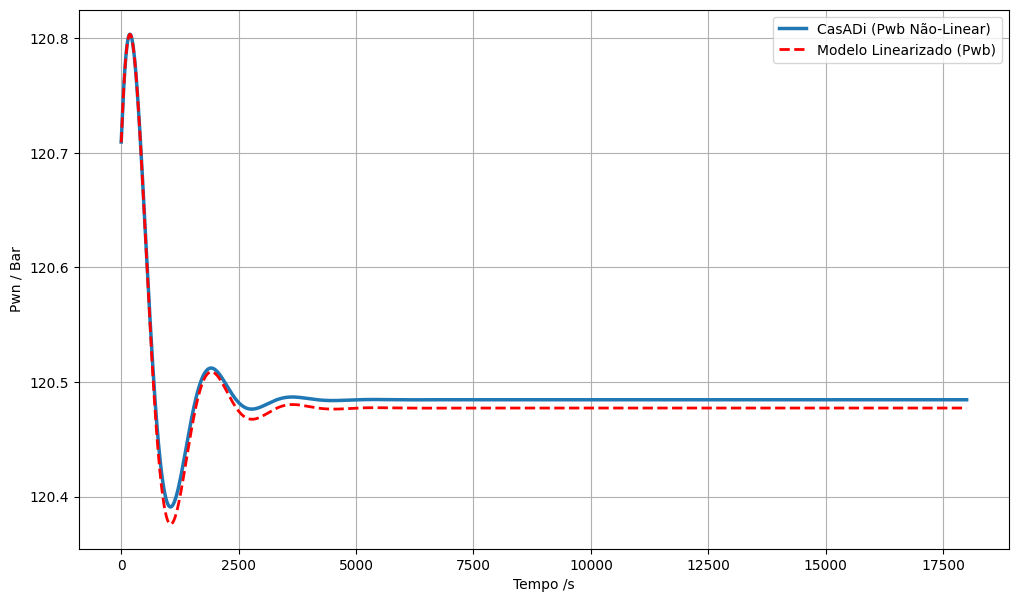


Valor Final (CasADi PWH): 120.4845 Bar
Valor Final (Linear PWH): 120.4773 Bar

--- Métricas de Erro (CasADi vs Linear) ---
Erro Quadrático Médio (MSE): 0.0001 (Bar²)
Raiz do Erro (RMSE):       0.0074 (Bar)


In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error # <-- Importa a função MSE



X_eq_vals = np.array([
    1713.946,    # mean_x1 (Equilíbrio do Estado 1)
    424.3868,    # mean_x2 (Equilíbrio do Estado 2)
    4454.146     # mean_x3 (Equilíbrio do Estado 3)
])

# U_eq_vals = [w_inj, u1, GOR]
U_eq_vals = np.array([
    1.2,     # w_inj (Equilíbrio da Entrada 1)
    0.8,     # u1    (Equilíbrio da Entrada 2)
    0.01     # GOR   (Equilíbrio da Entrada 3)
])

t0, tf, dt = 0, 18000, 1
t = np.arange(t0, tf, dt)
t_pontos = len(t)


y0 = X_eq_vals 
z0_vals = np.array([
    7183839.554, 2991744.663, 7138588.549, 12043588.55,
    1.90714269, 14.13695208, 33.43556308, 2.911066071,
    30.52449701, 0.141369521, 281.8106616, 80.37817471
])

w_inj = 1.24
u1 = 0.8
GOR = 0.01
params = np.array([w_inj, u1, GOR])



integrador, modelo = fun_integrador(dt=1)
results_casadi = simular_2(integrador, modelo, params, y0, z0_vals, t)
print("Simulação CasADi concluída.")

# Extrai o Pwb (em Pascals)
y_casadi_pwh_pa = results_casadi['Pwb']



print("Iniciando simulação Scipy (Linearizada)...")

# 1. Desvio da Entrada (u' = u - u_eq)
magnitudes_degrau = params - U_eq_vals
U_desvio = np.ones((t_pontos, 1)) * magnitudes_degrau

# 2. Desvio da Condição Inicial (x' = x0 - x_eq)
x0_desvio = y0 - X_eq_vals  # (Resultado: [0, 0, 0])

# 3. Definir o sistema LTI
sistema_lti_tuple = (A, B, C, D)

print(f"  Tempo: t=0 a t={tf}")
print(f"  Desvio de Entrada (u'): {magnitudes_degrau}")
print(f"  Desvio Inicial (x0'): {x0_desvio}")

# 4. Simular!
t_out, y_out_desvio, x_out = signal.lsim(sistema_lti_tuple, 
                                        U_desvio, 
                                        t, 
                                        X0=x0_desvio)


y_abs_pa = y_out_desvio + Y_eq[0]


y_linear_pwh_bar = y_abs_pa / 100000.0 


print("Simulação Linearizada concluída.")


plt.figure(figsize=(12, 7))
y_casadi_pwh_bar = None # Inicializa a variável


if y_casadi_pwh_pa is not None:

    y_casadi_pwh_bar = y_casadi_pwh_pa / 100000.0
   
    plt.plot(t, y_casadi_pwh_bar, label='CasADi (Pwb Não-Linear)', linewidth=2.5)

# Plotar o resultado do LTI (Linearizado)
plt.plot(t, y_linear_pwh_bar.flatten(), label='Modelo Linearizado (Pwb)', 
         linestyle='--', color='r', linewidth=2)


plt.xlabel('Tempo /s')
plt.ylabel('Pwn / Bar')
plt.legend()
plt.grid(True)
plt.show()

# Imprimir valores finais para comparação
if y_casadi_pwh_bar is not None:
    print(f"\nValor Final (CasADi PWH): {y_casadi_pwh_bar[-1]:.4f} Bar")
print(f"Valor Final (Linear PWH): {y_linear_pwh_bar[-1]:.4f} Bar")



if y_casadi_pwh_bar is not None:
    # y_true: O modelo "verdadeiro" (CasADi)
    y_true = y_casadi_pwh_bar # Já é (N,) e está em Bar
    
    # y_pred: O modelo aproximado (Linearizado)
    y_pred = y_linear_pwh_bar.flatten() # Converte de (N,1) para (N,)
    
    # Calcular o MSE
    mse = mean_squared_error(y_true, y_pred)
    
    print(f"\n--- Métricas de Erro (CasADi vs Linear) ---")
    print(f"Erro Quadrático Médio (MSE): {mse:.4f} (Bar²)")
    
    # O RMSE (Raiz do MSE) é mais fácil de interpretar, pois está na unidade (Bar)
    rmse = np.sqrt(mse)
    print(f"Raiz do Erro (RMSE):       {rmse:.4f} (Bar)")
    
else:
    print("\nNão foi possível calcular o MSE (simulação CasADi falhou).")